# Iris データセット探索

このノートブックでは、Iris データセットの探索的データ分析（EDA）を行います。

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# スタイル設定（フォント設定の前に実行）
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# 日本語フォント設定（自動検出）
japanese_fonts = [
    'MS Gothic',        # Windows
    'Yu Gothic',        # Windows
    'Meiryo',           # Windows
    'Hiragino Sans',    # macOS
    'IPAexGothic',      # Linux
    'Noto Sans CJK JP'  # Linux
]

# 利用可能なフォントを検索
available_fonts = [f.name for f in fm.fontManager.ttflist]
selected_font = None

for font in japanese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = selected_font
    print(f"日本語フォント: {selected_font} を使用します")
else:
    print("警告: 日本語フォントが見つかりませんでした。デフォルトフォントを使用します。")

# マイナス記号が文字化けしないように設定
plt.rcParams['axes.unicode_minus'] = False

print(f"現在のフォント設定: {plt.rcParams['font.family']}")

## 1. データ読み込み

In [2]:
# Iris データセットを読み込む
df = pd.read_csv('../data/iris.csv')

print(f"データ件数: {len(df)} 件")
print(f"特徴量数: {len(df.columns) - 1} 個")
print("\n最初の5行:")
df.head()

データ件数: 150 件
特徴量数: 4 個

最初の5行:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. データの基本統計

In [3]:
# 基本統計量
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# 品種ごとの件数
print("品種ごとの件数:")
print(df['species'].value_counts())

# 品種ごとの割合
print("\n品種ごとの割合:")
print(df['species'].value_counts(normalize=True))

品種ごとの件数:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

品種ごとの割合:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


## 3. データの可視化

C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\396373561.py:15: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\396373561.py:15: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\396373561.py:15: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\396373561.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\396373561.py:15: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:1

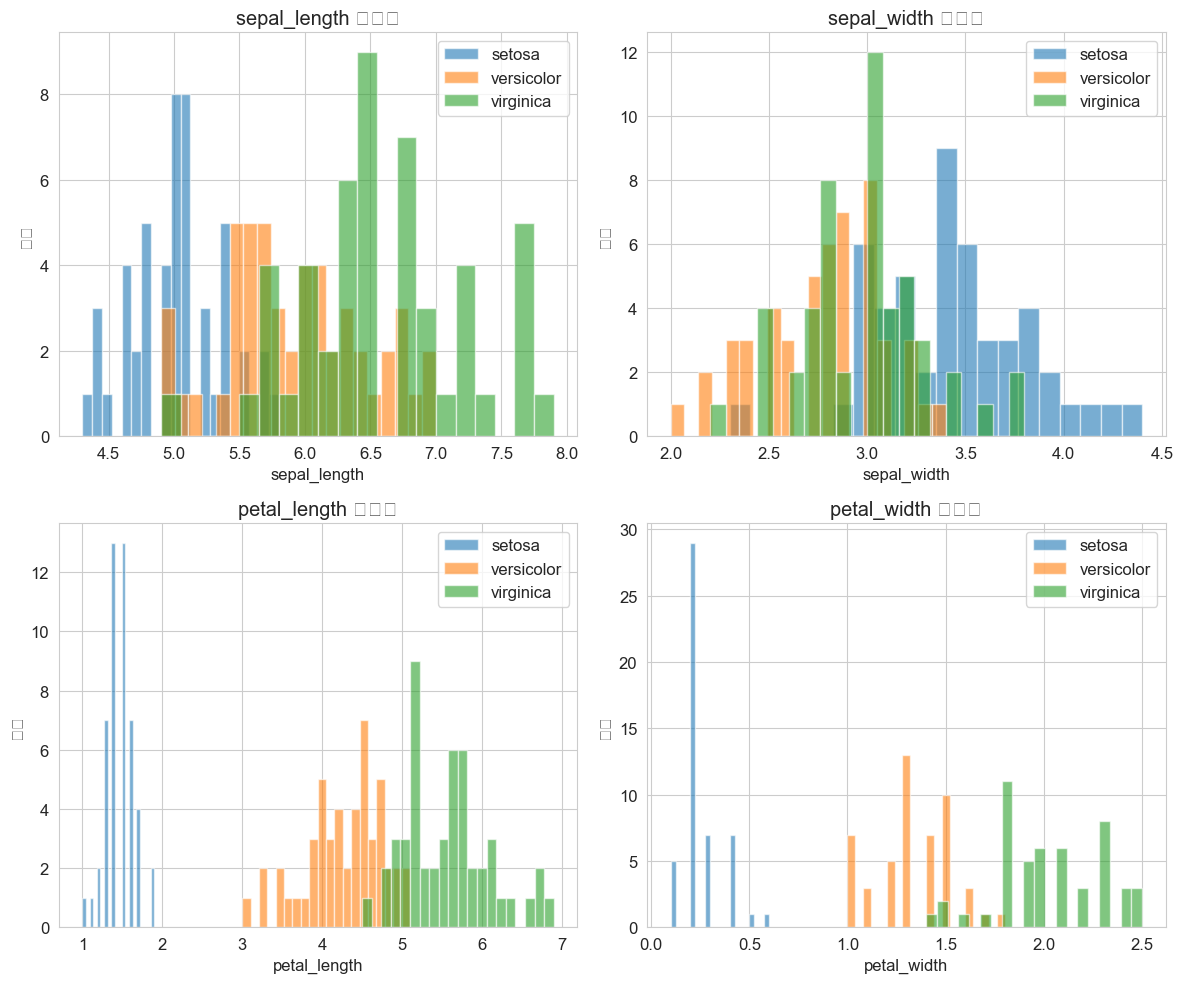

In [5]:
# 特徴量の分布（ヒストグラム）
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]
    for species in df['species'].unique():
        data = df[df['species'] == species][feature]
        ax.hist(data, alpha=0.6, label=species, bins=20)
    ax.set_xlabel(feature)
    ax.set_ylabel('頻度')
    ax.legend()
    ax.set_title(f'{feature} の分布')

plt.tight_layout()
plt.show()

C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\142618675.py:11: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\142618675.py:11: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\142618675.py:11: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\142618675.py:11: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\142618675.py:11: UserWarning: Glyph 12402 (\N{HIRAGANA LETTER HI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC202411-1\AppData\Local\Temp\ipykernel_34084\142618675.py:11: UserWarning: Glyph 12370 (\N{HIRAGANA LETTER GE})

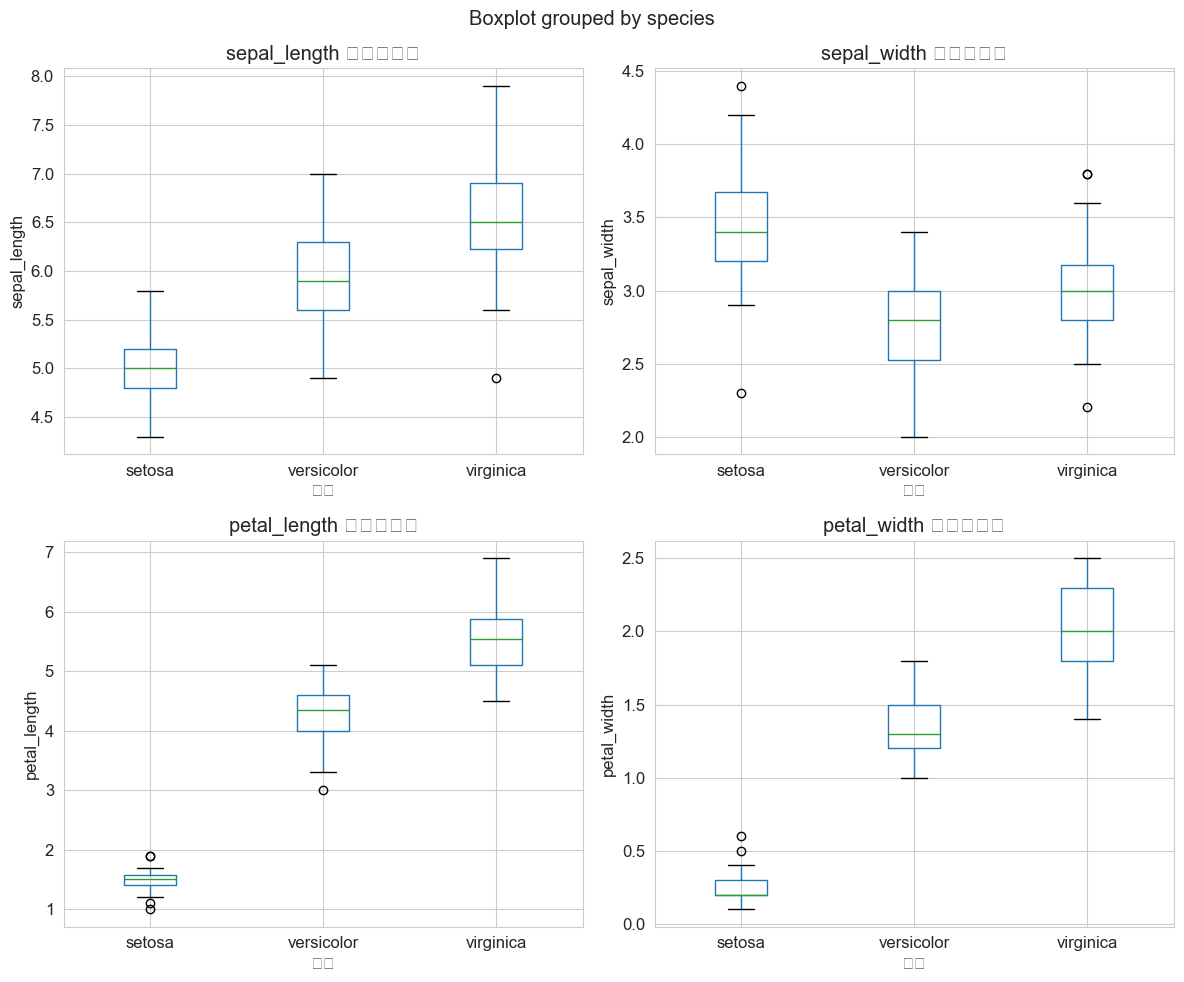

In [6]:
# 箱ひげ図
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]
    df.boxplot(column=feature, by='species', ax=ax)
    ax.set_xlabel('品種')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} の箱ひげ図')

plt.tight_layout()
plt.show()

C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12475 (\N{KATAKANA LETTER SE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects

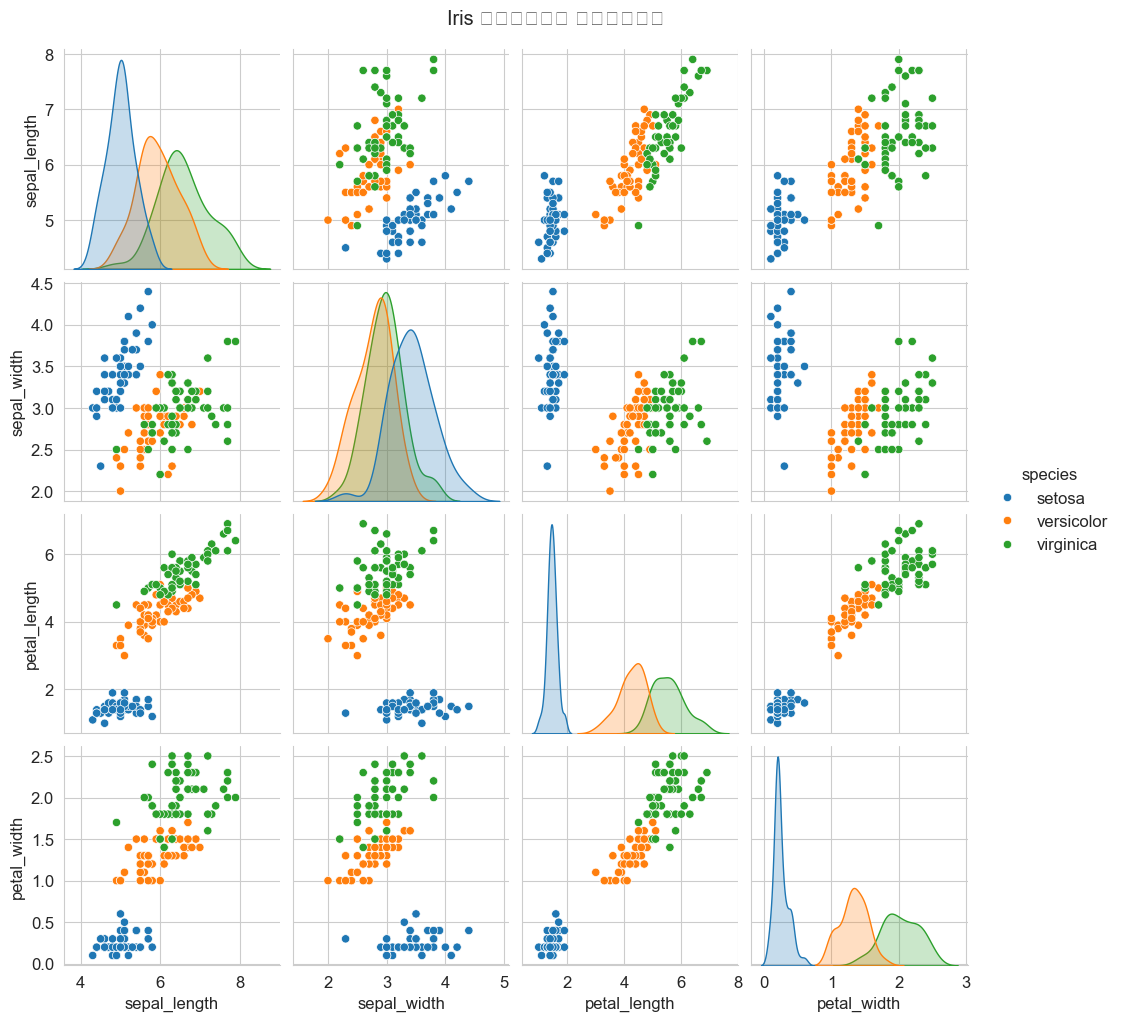

In [7]:
# ペアプロット
sns.pairplot(df, hue='species', diag_kind='kde', height=2.5)
plt.suptitle('Iris データセット ペアプロット', y=1.02)
plt.show()

## 4. 相関分析

C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProj

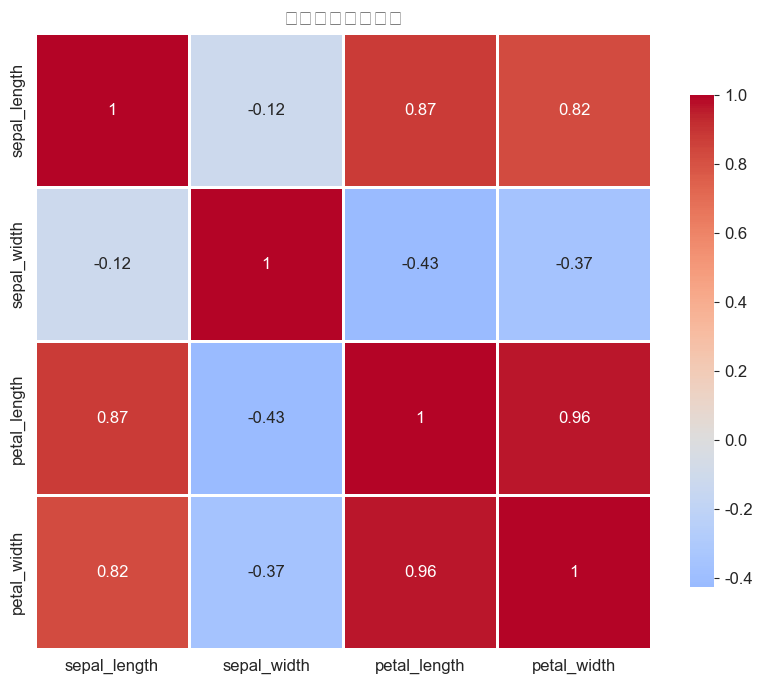

In [8]:
# 相関行列
correlation_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('特徴量の相関行列')
plt.show()

## 5. 品種ごとの特徴量の平均値

品種ごとの特徴量平均値:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\rust\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC202411-1\

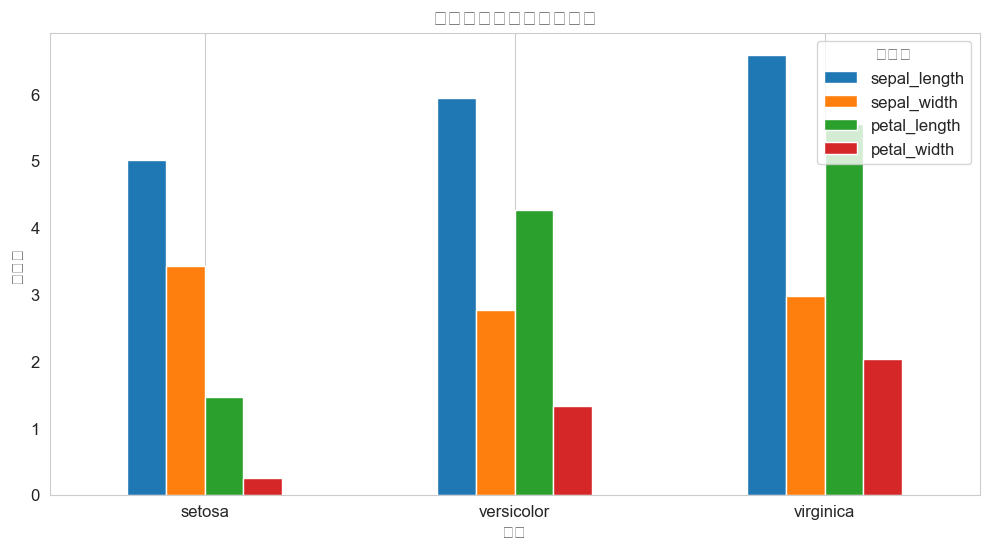

In [9]:
# 品種ごとの平均値
species_means = df.groupby('species')[features].mean()
print("品種ごとの特徴量平均値:")
print(species_means)

# 可視化
species_means.plot(kind='bar', figsize=(12, 6))
plt.title('品種ごとの特徴量平均値')
plt.xlabel('品種')
plt.ylabel('平均値')
plt.xticks(rotation=0)
plt.legend(title='特徴量')
plt.grid(axis='y')
plt.show()

## 6. 2次元散布図（主要な特徴量）

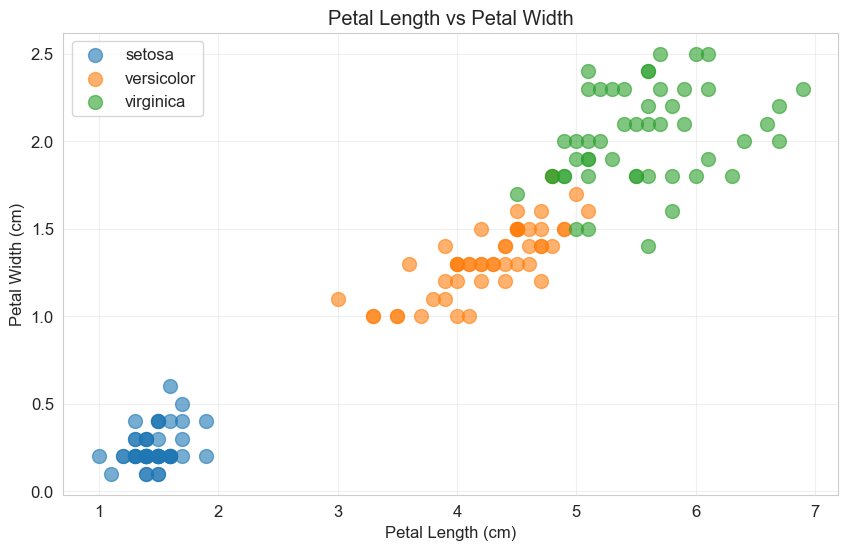

In [10]:
# petal_length vs petal_width
plt.figure(figsize=(10, 6))
for species in df['species'].unique():
    data = df[df['species'] == species]
    plt.scatter(data['petal_length'], data['petal_width'], 
                label=species, alpha=0.6, s=100)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

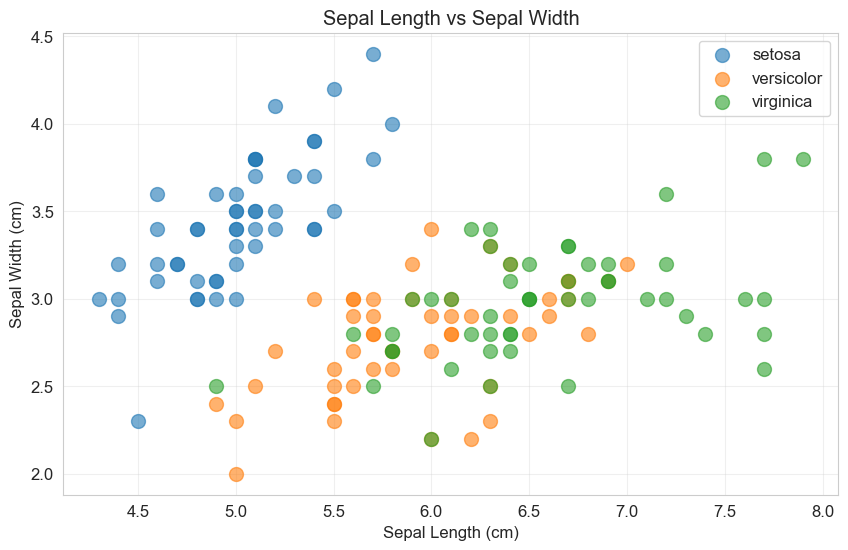

In [11]:
# sepal_length vs sepal_width
plt.figure(figsize=(10, 6))
for species in df['species'].unique():
    data = df[df['species'] == species]
    plt.scatter(data['sepal_length'], data['sepal_width'], 
                label=species, alpha=0.6, s=100)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. まとめ

### 主な観察結果:

1. **データバランス**: 3つの品種はそれぞれ50件ずつで、完全にバランスが取れている

2. **特徴量の分離性**:
   - petal_length と petal_width は品種を非常によく分離できる
   - setosa は他の2種と明確に分離できる
   - versicolor と virginica は部分的に重なる

3. **相関**:
   - petal_length と petal_width は強い正の相関
   - sepal_length と petal_length も正の相関

4. **分類の見通し**:
   - Decision Tree は特徴量の閾値で分類するため、このデータセットに適している
   - 高い精度が期待できる（特に setosa の分類）